# 서울특별시 아파트 매매 실거래가 분석 (2015~2025)
### 데이터마이닝 기말 프로젝트

디지털소프트웨어공학과 20242550 최현진

**데이터 출처**
- 아파트 실거래가: 국토교통부 실거래가공개시스템 (https://rt.molit.go.kr)
- 금리 데이터: 한국은행 경제통계시스템 ECOS (https://ecos.bok.or.kr)


**작업 순서**
1. 라이브러리
2. 아파트 CSV 11개 병합
3. 클리닝 & 파생변수
4. 이상치 처리
5. 브랜드 분류
6. 전처리 마무리
7. 금리 데이터 4개 병합
8. 분석용 데이터 합치기 (전처리 + 금리)
9. 전체 분포 확인
10. 구별 분석
11. 연도별 추이
12. 금리랑 매매가 관계
13. 브랜드별 분석
14. 코로나 시기 전후 비교

> 파일 저장은 안 함. 노트북에서 바로 확인만.

**경로 2개**: 아파트 CSV 폴더, 금리 엑셀 들어있는 merge 폴더 - 본인 컴퓨터 경로로 맞춰놓음

## 1. 라이브러리

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from functools import reduce
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 강제 적용 - 시스템에 설치된 폰트 목록에서 직접 찾아서 지정
# (그냥 이름만 적으면 캐시 문제로 안 먹는 경우가 있어서, 실제 설치된 폰트를 검색해서 확실하게 잡음)
korean_fonts = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR']
installed_fonts = {f.name for f in fm.fontManager.ttflist}

found_font = None
for font_name in korean_fonts:
    if font_name in installed_fonts:
        found_font = font_name
        break

if found_font:
    plt.rcParams['font.family'] = found_font
    print(f"한글 폰트 적용됨: {found_font}")
else:
    print("한글 폰트를 못찾음 - 그래프에 한글이 깨질 수 있음")
    print("설치된 폰트 일부:", sorted(installed_fonts)[:20])

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# sns.set_style을 폰트 설정 뒤에 호출 - seaborn이 먼저 호출되면 폰트가 기본값으로 되돌아가는 경우가 있음
sns.set_style('whitegrid')
plt.rcParams['font.family'] = found_font if found_font else plt.rcParams['font.family']  # 한번 더 확실하게


한글 폰트 적용됨: Malgun Gothic


> 그래프에 한글 깨져서 □□□ 나오면 폰트 문제임
> - 윈도우: Malgun Gothic 기본 있으니까 위 코드 그대로
> - 맥: AppleGothic으로 바꾸기
> - 리눅스 쓸 일은 없겠지만 혹시나 하면 나눔고딕 설치

## 2. CSV 읽는 함수

국토부에서 받은 CSV는 다 똑같은 구조임
- 인코딩 CP949
- 앞에 15줄 정도는 안내문이고 진짜 헤더는 그 다음에 나옴
- 거래금액에 천단위 콤마 들어있어서 그냥 읽으면 문자열로 잡힘

연도마다 안내문 줄 수가 살짝 다를 수 있어서 skiprows 고정값 쓰면 위험함.
그래서 "NO"로 시작하는 줄을 찾아서 거기서부터 읽게 함 - 이러면 몇 번째 줄이든 상관없음.

In [2]:
def load_molit_csv(filepath, encoding='cp949'):
    # 헤더("NO" 시작하는 줄) 위치를 자동으로 찾음
    header_row = None
    with open(filepath, encoding=encoding) as f:
        for i, line in enumerate(f):
            if line.startswith('"NO"') or line.startswith('NO,'):
                header_row = i
                break
    if header_row is None:
        raise ValueError(f"헤더를 못찾음: {filepath}")

    df = pd.read_csv(
        filepath,
        encoding=encoding,
        skiprows=header_row,
        thousands=',',
        dtype={'본번': str, '부번': str, '번지': str}  # 0으로 시작하는 번지 깨지는거 방지
    )

    df.columns = [c.strip() for c in df.columns]
    df['__source_file'] = os.path.basename(filepath)
    return df


def load_all_years(data_dir, pattern='*.csv'):
    # 폴더 안 CSV 다 읽어서 하나로 합침
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(f"{data_dir} 에 {pattern} 파일이 없음")

    print(f"파일 {len(files)}개 발견:")
    dfs = []
    for fp in files:
        try:
            df = load_molit_csv(fp)
            ym_min, ym_max = df['계약년월'].min(), df['계약년월'].max()
            print(f"  - {os.path.basename(fp):45s} {len(df):>7,}행  계약년월 {ym_min}~{ym_max}")
            dfs.append(df)
        except Exception as e:
            print(f"  ! 실패: {os.path.basename(fp)} -> {e}")

    combined = pd.concat(dfs, ignore_index=True, sort=False)
    print(f"\n합치기 완료: 총 {len(combined):,}행, {combined.shape[1]}개 컬럼")
    return combined


## 3. 데이터 로드

DATA_DIR에 CSV 11개 들어있는 폴더 경로 넣으면 됨

In [3]:
DATA_DIR = r'C:\Users\user\Desktop\서울특별시 아파트 실거래가 분석_데이터 마이닝'
FILE_PATTERN = '*.csv'

raw = load_all_years(DATA_DIR, FILE_PATTERN)
raw.head()


파일 11개 발견:
  - 아파트(매매)_실거래가_20260620141002.csv               120,039행  계약년월 201501~201512
  - 아파트(매매)_실거래가_20260620141128.csv               110,085행  계약년월 201601~201612
  - 아파트(매매)_실거래가_20260620141307.csv               104,930행  계약년월 201701~201712
  - 아파트(매매)_실거래가_20260620141323.csv                81,579행  계약년월 201801~201812
  - 아파트(매매)_실거래가_20260620141334.csv                74,999행  계약년월 201901~201912
  - 아파트(매매)_실거래가_20260620141343.csv                84,017행  계약년월 202001~202012
  - 아파트(매매)_실거래가_20260620141407.csv                43,429행  계약년월 202101~202112
  - 아파트(매매)_실거래가_20260620141419.csv                12,801행  계약년월 202201~202212
  - 아파트(매매)_실거래가_20260620141539.csv                35,583행  계약년월 202301~202312
  - 아파트(매매)_실거래가_20260620141551.csv                57,749행  계약년월 202401~202412
  - 아파트(매매)_실거래가_20260620141611.csv                83,776행  계약년월 202501~202512

합치기 완료: 총 808,987행, 21개 컬럼


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,__source_file
0,1,서울특별시 광진구 자양동,665,0665,0000,그린,75.3200,201512,31,35300,-,2,-,-,2003,뚝섬로56길 35,-,-,-,-,아파트(매매)_실거래가_20260620141002.csv
1,2,서울특별시 종로구 숭인동,766,0766,0000,종로청계힐스테이트,84.9478,201512,31,52500,-,11,-,-,2009,숭인동길 21,-,-,-,-,아파트(매매)_실거래가_20260620141002.csv
2,3,서울특별시 광진구 자양동,516,0516,0000,우성3,84.9100,201512,31,65200,-,8,-,-,1989,뚝섬로35길 32,-,-,-,-,아파트(매매)_실거래가_20260620141002.csv
3,4,서울특별시 동대문구 답십리동,493-5,0493,0005,클래식타워,120.2400,201512,31,40000,-,12,-,-,1999,천호대로 307,-,-,-,-,아파트(매매)_실거래가_20260620141002.csv
4,5,서울특별시 동대문구 답십리동,999,0999,0000,청계벽산메가트리움,84.9600,201512,31,39700,-,2,-,-,2006,천호대로 241,-,-,-,-,아파트(매매)_실거래가_20260620141002.csv


In [4]:
# 행 개수 맞는지, 중복 있는지 체크
print(f"전체 행 수: {len(raw):,}")
print(f"완전 중복 행 수: {raw.duplicated().sum():,}")

print()
print("=== 파일별 컬럼 개수 비교 ===")
for f, g in raw.groupby('__source_file'):
    cols = set(g.columns) - {'__source_file'}
    print(f"{f}: {len(cols)}개 컬럼")


전체 행 수: 808,987
완전 중복 행 수: 0

=== 파일별 컬럼 개수 비교 ===
아파트(매매)_실거래가_20260620141002.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141128.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141307.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141323.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141334.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141343.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141407.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141419.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141539.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141551.csv: 20개 컬럼
아파트(매매)_실거래가_20260620141611.csv: 20개 컬럼


> 국토부 데이터는 다운받는 시점이 겹치면 같은 거래가 중복으로 들어올 수 있음
> (예: 12월에 받은 파일이랑 1월에 받은 파일이 일부 겹치는 경우)
> 중복 있으면 다음 셀에서 제거함. NO, __source_file 컬럼은 파일마다 다르니까 중복판정에서 뺌

In [5]:
dedup_cols = [c for c in raw.columns if c not in ('NO', '__source_file')]
before = len(raw)
raw = raw.drop_duplicates(subset=dedup_cols).reset_index(drop=True)
after = len(raw)
print(f"중복 제거: {before:,} -> {after:,}행 ({before - after:,}건 제거)")


중복 제거: 808,987 -> 804,556행 (4,431건 제거)


## 4. 클리닝 & 파생변수

여기서 하는거:
1. 해제사유발생일이 '-' 아닌 행 = 계약 취소된 거래. 나중에 가격분석 왜곡되니까 플래그만 해둠
2. 계약년월 -> 연/월 나누고 계약일자도 datetime으로
3. 거래금액 억원 단위도 같이 만듦 (보기 편하게)
4. 평당가 계산 (1평 = 3.3058㎡)
5. 시군구 -> 구/동 분리
6. 단지ID 만들어서 같은 단지를 여러 연도에 걸쳐 추적 가능하게

In [6]:
def clean_and_enrich(df):
    df = df.copy()

    # 취소건 분리
    if '해제사유발생일' in df.columns:
        df['is_cancelled'] = df['해제사유발생일'].notna() & (df['해제사유발생일'] != '-')
    else:
        df['is_cancelled'] = False

    # 날짜 파생
    df['계약년월'] = df['계약년월'].astype(str)
    df['연도'] = df['계약년월'].str[:4].astype(int)
    df['월'] = df['계약년월'].str[4:6].astype(int)
    df['계약일'] = df['계약일'].astype(int)
    df['계약일자'] = pd.to_datetime(
        df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2) + '-' + df['계약일'].astype(str).str.zfill(2),
        errors='coerce'
    )

    # 금액/면적 파생
    df['거래금액(원)'] = df['거래금액(만원)'].astype(float) * 10_000
    df['거래금액(억원)'] = df['거래금액(만원)'].astype(float) / 10_000
    df['평형'] = df['전용면적(㎡)'] / 3.3058
    df['평당가(만원)'] = df['거래금액(만원)'] / df['평형']

    # 지역 파생
    addr_split = df['시군구'].str.split(' ', expand=True)
    df['시도'] = addr_split[0]
    df['구'] = addr_split[1]
    df['동'] = addr_split[2] if addr_split.shape[1] > 2 else np.nan

    # 단지ID (연도 넘어서 같은 단지 추적용)
    df['단지ID'] = df['구'].astype(str) + '_' + df['동'].astype(str) + '_' + df['번지'].astype(str) + '_' + df['단지명'].astype(str)

    # 평형대 구간
    area_bins = [0, 40, 60, 85, 102, 135, np.inf]
    area_labels = ['소형(~40㎡)', '소형(40~60㎡)', '국민평형(60~85㎡)', '중형(85~102㎡)', '대형(102~135㎡)', '초대형(135㎡~)']
    df['평형대'] = pd.cut(df['전용면적(㎡)'], bins=area_bins, labels=area_labels)

    return df


df = clean_and_enrich(raw)

print(f"전체: {len(df):,}건")
print(f"취소 건: {df['is_cancelled'].sum():,}건 ({df['is_cancelled'].mean()*100:.1f}%)")
print(f"정상 거래: {(~df['is_cancelled']).sum():,}건")
print()
print(f"기간: {df['연도'].min()} ~ {df['연도'].max()}")
print(f"구 개수: {df['구'].nunique()}개 (25개 맞는지 체크)")
print(f"동 개수: {df['동'].nunique()}개")
print(f"단지 개수: {df['단지ID'].nunique()}개")


전체: 804,556건
취소 건: 15,610건 (1.9%)
정상 거래: 788,946건

기간: 2015 ~ 2025
구 개수: 25개 (25개 맞는지 체크)
동 개수: 337개
단지 개수: 9081개


In [7]:
# 연도별로 건수 이상한거 없는지
print(df.groupby('연도').size())


연도
2015    119660
2016    109813
2017    104660
2018     81293
2019     74607
2020     83597
2021     43113
2022     12294
2023     35174
2024     57371
2025     82974
dtype: int64


In [8]:
# 결측치 체크
print("=== 핵심 컬럼 결측치 ===")
print(df[['거래금액(만원)', '전용면적(㎡)', '연도', '구', '동', '계약일자']].isnull().sum())
print()

# 구가 25개 아니면 시군구 파싱 깨진 행 있다는 뜻
if df['구'].nunique() != 25:
    print("구 개수가 25개가 아님. 확인 필요:")
    print(df[df['구'].isnull()][['시군구']].drop_duplicates())


=== 핵심 컬럼 결측치 ===
거래금액(만원)    0
전용면적(㎡)     0
연도          0
구           0
동           0
계약일자        0
dtype: int64



## 5. 이상치 플래그

실거래가에는 친족간 거래나 증여성 매매처럼 시세랑 동떨어진 거래가 섞여있음
(평당가 비정상적으로 낮으면 사실상 증여일 가능성 높음)

완전히 지우진 않고 구별 평당가 상하위 1%만 플래그 해둠 -> 나중에 분석할때 빼고 보면 됨

In [9]:
def flag_outliers_by_gu(df, col='평당가(만원)', lower_q=0.01, upper_q=0.99):
    df = df.copy()
    bounds = df.groupby('구')[col].quantile([lower_q, upper_q]).unstack()
    bounds.columns = ['lower', 'upper']
    df = df.merge(bounds, left_on='구', right_index=True, how='left')
    df['is_price_outlier'] = (df[col] < df['lower']) | (df[col] > df['upper'])
    df = df.drop(columns=['lower', 'upper'])
    return df

df = flag_outliers_by_gu(df)
print(f"이상치(구별 상하위 1%) 플래그: {df['is_price_outlier'].sum():,}건 ({df['is_price_outlier'].mean()*100:.1f}%)")


이상치(구별 상하위 1%) 플래그: 16,100건 (2.0%)


In [10]:
# 이상치 샘플 눈으로 확인
print("=== 평당가 최하위 5건 (저가성 의심) ===")
print(df.nsmallest(5, '평당가(만원)')[['연도','구','동','단지명','전용면적(㎡)','거래금액(만원)','평당가(만원)']])
print()
print("=== 평당가 최상위 5건 ===")
print(df.nlargest(5, '평당가(만원)')[['연도','구','동','단지명','전용면적(㎡)','거래금액(만원)','평당가(만원)']])


=== 평당가 최하위 5건 (저가성 의심) ===
          연도     구      동       단지명  전용면적(㎡)  거래금액(만원)     평당가(만원)
63753   2015   성동구  하왕십리동  텐즈힐(1단지)    84.96       700   27.237053
210922  2016  영등포구  당산동1가       코오롱    68.88      1100   52.792973
213111  2016  서대문구   북아현동     북아현경남    84.91      3000  116.798964
106158  2015   구로구    구로동  (770-23)    74.06      4000  178.547124
72997   2015  동대문구   답십리동      신답경남    82.50      9000  360.632727

=== 평당가 최상위 5건 ===
          연도    구      동        단지명   전용면적(㎡)  거래금액(만원)       평당가(만원)
766134  2025  성동구  성수동1가  아크로서울포레스트  273.9280   2900000  34997.590608
770935  2025  성동구  성수동1가  아크로서울포레스트  198.2190   1870000  31186.949788
682270  2024  용산구    한남동      나인원한남  273.9424   2500000  30168.750803
799407  2025  용산구    한남동      나인원한남  273.9424   2500000  30168.750803
663006  2023  강남구    개포동    개포주공4단지   41.9900    370000  29129.459395


## 6. 아파트 브랜드 분류 (일반 vs 하이엔드)

단지명 컬럼에 이름이 수천개라 그대로는 브랜드 비교 못함.
주요 건설사 브랜드명이 단지명에 들어있는지 검사해서 브랜드 컬럼 만들고, 그 중에 하이엔드 라인은 따로 구분.

순서 중요함 - "래미안원베일리"는 래미안의 하이엔드 단지인데, 그냥 "래미안"으로 먼저 걸러버리면 일반 래미안으로 묶여버림.
그래서 하이엔드 특수단지를 제일 먼저 검사해야 함.

In [11]:
# 일반 브랜드
brand_list = [
    '래미안', '자이', '힐스테이트', '푸르지오', 'e편한세상',
    '더샵', '롯데캐슬', '아이파크', '포레나', 'SK뷰'
]

# 하이엔드 브랜드
# 리스트 항목 끝에 쉼표 빠지면 문자열 두개가 붙어버리니까 수정할때 조심
highend_brand_list = [
    '아크로',
    '오티에르',
    '르엘',
    '드파인',
    '디에이치',
    '써밋',
    '래미안원베일리',
    '래미안원펜타스',
]


In [12]:
def classify_brand(apartment_name):
    # 단지명 받아서 브랜드 반환. 못찾으면 '기타'
    # 검사 순서 중요함:
    # 1) 래미안 하이엔드 단지(원베일리/원펜타스) 먼저
    # 2) 나머지 하이엔드 브랜드
    # 3) 일반 브랜드

    apartment_name = str(apartment_name)  # NaN 들어와도 에러 안나게
    name_upper = apartment_name.upper()

    # 1) 래미안 하이엔드 특수단지 - 일반 래미안보다 먼저 체크해야됨
    # '레미안'은 '래미안' 오타/이체자 표기라 같이 처리
    if '래미안원베일리' in apartment_name:
        return '래미안원베일리'
    if '래미안원펜타스' in apartment_name or '레미안원펜타스' in apartment_name:
        return '래미안원펜타스'

    # 2) 그 외 하이엔드
    for brand in highend_brand_list:
        if brand in ('래미안원베일리', '래미안원펜타스'):
            continue  # 위에서 이미 처리함
        if brand in apartment_name:
            return brand

    # 3) 일반 브랜드
    if '래미안' in apartment_name or '레미안' in apartment_name:
        return '래미안'
    if '자이' in apartment_name:
        return '자이'
    if '힐스테이트' in apartment_name:
        return '힐스테이트'
    if '푸르지오' in apartment_name:
        return '푸르지오'
    if (
        'e편한세상' in apartment_name or 'e-편한세상' in apartment_name
        or '이편한세상' in apartment_name or '이편한' in apartment_name
    ):
        return 'e편한세상'
    if '더샵' in apartment_name or '더샾' in apartment_name or 'THE SHARP' in name_upper:
        return '더샵'
    if '롯데캐슬' in apartment_name or '롯데케슬' in apartment_name:
        return '롯데캐슬'
    if (
        '아이파크' in apartment_name
        or 'IPARK' in name_upper or 'I-PARK' in name_upper or 'I PARK' in name_upper
    ):
        return '아이파크'
    if '포레나' in apartment_name or 'FORENA' in name_upper:
        return '포레나'
    if (
        'SK뷰' in apartment_name or '에스케이뷰' in apartment_name
        or 'SKVIEW' in name_upper or 'SK VIEW' in name_upper
    ):
        return 'SK뷰'

    return '기타'


In [13]:
# 브랜드 컬럼 생성
df['브랜드'] = df['단지명'].apply(classify_brand)

print("=== 브랜드별 거래 건수 ===")
print(df['브랜드'].value_counts())
print()
print(f"브랜드 없는('기타') 비율: {(df['브랜드'] == '기타').mean() * 100:.1f}%")


=== 브랜드별 거래 건수 ===
브랜드
기타         643190
래미안         52577
푸르지오        18979
힐스테이트       18887
자이          15825
e편한세상       15282
롯데캐슬        14500
아이파크        14159
더샵           3741
아크로          2909
SK뷰          2184
써밋           1273
디에이치          396
포레나           388
래미안원베일리       163
르엘             93
래미안원펜타스        10
Name: count, dtype: int64

브랜드 없는('기타') 비율: 79.9%


In [14]:
# 일반/하이엔드/기타 구분하는 브랜드등급 컬럼도 추가
# -> groupby('브랜드등급') 한줄이면 일반 vs 하이엔드 비교 바로 됨

def classify_brand_tier(brand):
    if brand in highend_brand_list:
        return '하이엔드'
    elif brand in brand_list:
        return '일반브랜드'
    else:
        return '기타(브랜드없음)'

df['브랜드등급'] = df['브랜드'].apply(classify_brand_tier)

print("=== 브랜드등급별 거래 건수 ===")
print(df['브랜드등급'].value_counts())
print()
print("=== 브랜드등급별 평당가(만원) 중위값 비교 ===")
print(df.groupby('브랜드등급')['평당가(만원)'].median().sort_values(ascending=False))


=== 브랜드등급별 거래 건수 ===
브랜드등급
기타(브랜드없음)    643190
일반브랜드        156522
하이엔드           4844
Name: count, dtype: int64

=== 브랜드등급별 평당가(만원) 중위값 비교 ===
브랜드등급
하이엔드         6420.418826
일반브랜드        3614.586035
기타(브랜드없음)    2538.328817
Name: 평당가(만원), dtype: float64


### 분류 결과 검증

1. 래미안원베일리/원펜타스가 일반 래미안 아니라 하이엔드로 따로 분류됐는지
2. '기타'로 빠진 단지명 샘플 직접 보면서 놓친 브랜드 있나 확인 (있으면 brand_list에 추가)

In [15]:
# 1) 원베일리/원펜타스 확인
print(df[df['단지명'].str.contains('래미안원베일리|래미안원펜타스|레미안원펜타스', na=False)]
      [['단지명', '브랜드', '브랜드등급']].drop_duplicates())


            단지명      브랜드 브랜드등급
630872  래미안원베일리  래미안원베일리  하이엔드
672963  래미안원펜타스  래미안원펜타스  하이엔드


In [16]:
# 2) '기타' 단지명 30개 무작위로 확인
df[df['브랜드'] == '기타']['단지명'].drop_duplicates().sample(30, random_state=42)


46574                 별장
38619           (752-45)
105085    무지개아파트(308-86)
58939         토미빌(228-9)
4504           논현동한화꿈에그린
47796                마이유
131192             로얄팰리스
190                   한신
454             일두(1021)
115878          삼환SOGOOD
3651                 아데나
37525            아이에스빌리브
151              SK허브프리모
726626          천호역마에스트로
246205             디엠씨엘가
632          마곡엠벨리(14단지)
584498             이스턴잠실
611414     힐데스하임올림픽파크아파트
82663                 창동
333069          (739-43)
27730             휴먼아파트B
41660              파크카운티
5424                  우당
2951                  은행
47182               월든힐스
36614        세진(1037-31)
10380                대상3
2347                  동양
102778            노보빌아파트
29262                 성용
Name: 단지명, dtype: str

## 7. 전처리 마무리

원본 컬럼 다 가진 버전이랑, 분석에 바로 쓸 핵심 컬럼만 추린 가벼운 버전 둘 다 만들어둠

In [17]:
# 전체 컬럼 버전
output_cols_full = list(df.columns)

# 분석용 핵심 컬럼만
core_cols = [
    '연도', '월', '계약일자', '구', '동', '시군구', '단지명', '단지ID',
    '브랜드', '브랜드등급',
    '전용면적(㎡)', '평형대', '건축년도', '층',
    '거래금액(만원)', '거래금액(억원)', '평당가(만원)',
    'is_cancelled', 'is_price_outlier', '__source_file'
]
core_cols = [c for c in core_cols if c in df.columns]

df_core = df[core_cols].copy()

print(f"전체 컬럼 버전: {df.shape}")
print(f"핵심 컬럼 버전: {df_core.shape}")
df_core.head()


전체 컬럼 버전: (804556, 36)
핵심 컬럼 버전: (804556, 20)


,연도,월,계약일자,구,동,시군구,단지명,단지ID,브랜드,브랜드등급,전용면적(㎡),평형대,건축년도,층,거래금액(만원),거래금액(억원),평당가(만원),is_cancelled,is_price_outlier,__source_file
0,2015,12,2015-12-31,광진구,자양동,서울특별시 광진구 자양동,그린,광진구_자양동_665_그린,기타,기타(브랜드없음),75.3200,국민평형(60~85㎡),2003,2,35300,3.53,1549.319437,False,False,아파트(매매)_실거래가_20260620141002.csv
1,2015,12,2015-12-31,종로구,숭인동,서울특별시 종로구 숭인동,종로청계힐스테이트,종로구_숭인동_766_종로청계힐스테이트,힐스테이트,일반브랜드,84.9478,국민평형(60~85㎡),2009,11,52500,5.25,2043.072334,False,False,아파트(매매)_실거래가_20260620141002.csv
2,2015,12,2015-12-31,광진구,자양동,서울특별시 광진구 자양동,우성3,광진구_자양동_516_우성3,기타,기타(브랜드없음),84.9100,국민평형(60~85㎡),1989,8,65200,6.52,2538.430809,False,False,아파트(매매)_실거래가_20260620141002.csv
3,2015,12,2015-12-31,동대문구,답십리동,서울특별시 동대문구 답십리동,클래식타워,동대문구_답십리동_493-5_클래식타워,기타,기타(브랜드없음),120.2400,대형(102~135㎡),1999,12,40000,4.00,1099.733866,False,True,아파트(매매)_실거래가_20260620141002.csv
4,2015,12,2015-12-31,동대문구,답십리동,서울특별시 동대문구 답십리동,청계벽산메가트리움,동대문구_답십리동_999_청계벽산메가트리움,기타,기타(브랜드없음),84.9600,국민평형(60~85㎡),2006,2,39700,3.97,1544.729991,False,False,아파트(매매)_실거래가_20260620141002.csv


In [18]:
# 파일 저장은 안하고 df_core 변수로 바로 다음 단계에서 씀
print(f"전처리 끝. df_core: {df_core.shape}")
print(f"브랜드/브랜드등급 포함됨")
print()
print("다음 단계에서 is_cancelled==False, is_price_outlier==False 로 걸러서 쓰면 됨")
print("예) df_trend = df_core[(~df_core['is_cancelled']) & (~df_core['is_price_outlier'])]")


전처리 끝. df_core: (804556, 20)
브랜드/브랜드등급 포함됨

다음 단계에서 is_cancelled==False, is_price_outlier==False 로 걸러서 쓰면 됨
예) df_trend = df_core[(~df_core['is_cancelled']) & (~df_core['is_price_outlier'])]


## 8. 금리 엑셀 구조 보기

한국은행 ECOS에서 받은 엑셀 4개 다 똑같은 구조임

| 행 | 내용 |
|---|---|
| 1행 | 제목 |
| 2행 | 주석 |
| 3행 | 출처 |
| 4행 | 범례명 (컬럼 이름) |
| 5행 | 단위 |
| 6행 | 주기(월/일) |
| 7행 | 기간 |
| 8행~ | 진짜 데이터 |

그래서 skiprows=7로 읽으면 됨

## 9. 월단위 파일 읽는 함수

가계대출/기업대출/여수신금리 3개가 여기 해당.
날짜가 "1996-01" 문자열로 들어있어서 하이픈 떼고 숫자로 바꿔서 계약년월 컬럼 만듦.
-> 아파트 데이터 계약년월(예: 201501)이랑 형식 똑같이 맞춰야 나중에 합칠 수 있음

In [19]:
def load_monthly_rate(filepath, col_names):
    # col_names: 범례명 보고 직접 지정한 한글 컬럼명
    df = pd.read_excel(filepath, skiprows=7, header=None)
    df.columns = ['date_str'] + col_names

    # "1996-01" -> "199601" 숫자로
    df['계약년월'] = df['date_str'].str.replace('-', '').astype(int)
    df = df.drop(columns=['date_str'])

    return df


## 10. 일단위 파일 읽는 함수 (기준금리 전용)

기준금리만 날짜가 "1999-05-06"처럼 일단위로 들어있음.
다른 3개랑 합치려면 월단위로 맞춰야돼서 같은 달끼리 평균내서 월단위로 압축함.

예) 2015년 3월에 기준금리 2.0% -> 1.75%로 월중에 내렸으면 3월 평균은 1.84% 정도로 계산됨

In [20]:
def load_daily_rate_as_monthly(filepath, col_names):
    df = pd.read_excel(filepath, skiprows=7, header=None)
    df.columns = ['date_str'] + col_names

    # 날짜 문자열 -> datetime
    df['date'] = pd.to_datetime(df['date_str'])

    # 연월만 뽑아서 "199905" 형태로
    df['계약년월'] = df['date'].dt.strftime('%Y%m').astype(int)

    # 같은 계약년월끼리 평균내서 일단위 -> 월단위로
    monthly = df.groupby('계약년월')[col_names].mean().reset_index()

    return monthly


### 금리 파일 경로

merge 폴더 경로. 위에 아파트 CSV용 DATA_DIR이랑 다른 변수니까 헷갈리지 말것

In [21]:
RATE_DATA_DIR = r'C:\Users\user\Desktop\서울특별시 아파트 실거래가 분석_데이터 마이닝\merge'


## 11. 4개 파일 불러오기

범례명(엑셀 4번째줄) 보고 컬럼명 직접 지정함

In [22]:
import os

household = load_monthly_rate(
    os.path.join(RATE_DATA_DIR, '예금은행 가계대출금리.xlsx'),
    ['가계대출금리', '주택담보대출금리', '일반신용대출금리']
)

corp = load_monthly_rate(
    os.path.join(RATE_DATA_DIR, '예금은행 기업대출금리.xlsx'),
    ['기업대출금리', '대기업대출금리', '중소기업대출금리']
)

deposit_loan = load_monthly_rate(
    os.path.join(RATE_DATA_DIR, '예금은행 여수신 금리.xlsx'),
    ['여신금리', '수신금리', '여수신금리차']
)

base_rate = load_daily_rate_as_monthly(
    os.path.join(RATE_DATA_DIR, '한국은행 기준금리 및 여수신금리.xlsx'),
    ['기준금리', '자금조정예금금리', '자금조정대출금리']
)

print('가계대출금리 :', household.shape)
print('기업대출금리 :', corp.shape)
print('여수신금리   :', deposit_loan.shape)
print('기준금리(월변환):', base_rate.shape)


가계대출금리 : (364, 4)
기업대출금리 : (364, 4)
여수신금리   : (364, 4)
기준금리(월변환): (326, 4)


In [23]:
household.head()


,가계대출금리,주택담보대출금리,일반신용대출금리,계약년월
0,12.52,NaN,NaN,199601
1,12.50,NaN,NaN,199602
2,12.46,NaN,NaN,199603
3,12.13,NaN,NaN,199604
4,12.09,NaN,NaN,199605


In [24]:
base_rate.head()


,계약년월,기준금리,자금조정예금금리,자금조정대출금리
0,199905,4.75,NaN,NaN
1,199906,4.75,NaN,NaN
2,199907,4.75,NaN,NaN
3,199908,4.75,NaN,NaN
4,199909,4.75,NaN,NaN


## 12. 4개 표 계약년월 기준으로 합치기

merge는 엑셀 VLOOKUP이랑 비슷한 개념. 계약년월 기준으로 같은 연월끼리 옆으로 붙임.

how='outer'로 하는 이유 - 4개 중 어느 한군데만 있는 연월도 안버리고 다 살림
(주담대금리는 2001년 9월부터 시작이라 그 전 데이터는 NaN으로 남겨둠. 손실 방지)

reduce는 household, corp, deposit_loan, base_rate 4개를 순서대로 하나씩 합치는거 한줄로 처리

In [25]:
rate_dfs = [household, corp, deposit_loan, base_rate]

merged_rates = reduce(
    lambda left, right: pd.merge(left, right, on='계약년월', how='outer'),
    rate_dfs
)

merged_rates = merged_rates.sort_values('계약년월').reset_index(drop=True)

# 계약년월을 맨 앞으로
cols = ['계약년월'] + [c for c in merged_rates.columns if c != '계약년월']
merged_rates = merged_rates[cols]

print('병합 완료:', merged_rates.shape)
merged_rates.head()


병합 완료: (366, 13)


,계약년월,가계대출금리,주택담보대출금리,일반신용대출금리,기업대출금리,대기업대출금리,중소기업대출금리,여신금리,수신금리,여수신금리차,기준금리,자금조정예금금리,자금조정대출금리
0,199601,12.52,NaN,NaN,11.14,11.69,11.05,11.43,10.42,1.01,NaN,NaN,NaN
1,199602,12.50,NaN,NaN,11.21,11.55,11.13,11.47,10.26,1.21,NaN,NaN,NaN
2,199603,12.46,NaN,NaN,11.11,11.40,11.05,11.37,10.33,1.04,NaN,NaN,NaN
3,199604,12.13,NaN,NaN,10.91,10.55,10.99,11.11,9.88,1.23,NaN,NaN,NaN
4,199605,12.09,NaN,NaN,11.10,11.69,10.94,11.24,9.62,1.62,NaN,NaN,NaN


In [26]:
merged_rates.tail()


,계약년월,가계대출금리,주택담보대출금리,일반신용대출금리,기업대출금리,대기업대출금리,중소기업대출금리,여신금리,수신금리,여수신금리차,기준금리,자금조정예금금리,자금조정대출금리
361,202602,4.45,4.32,5.53,4.20,4.13,4.28,4.26,2.83,1.43,2.5,2.0,3.0
362,202603,4.51,4.34,5.57,4.14,4.11,4.17,4.20,2.82,1.38,2.5,2.0,3.0
363,202604,4.43,4.31,5.63,4.14,4.09,4.18,4.20,2.92,1.28,2.5,2.0,3.0
364,202605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,2.0,3.0
365,202606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,2.0,3.0


## 13. 병합 결과 검증

체크할거 3개:
1. 계약년월 중복 없는지 (있으면 merge 잘못된거)
2. 분석할 2015~2025 구간 결측치 있는지
3. 전체 결측치 (이건 정상임 - 통계 시작 시점이 컬럼마다 다름)

In [27]:
# 1) 중복 체크
dup_count = merged_rates['계약년월'].duplicated().sum()
print(f'계약년월 중복: {dup_count}건 (0이어야 정상)')


계약년월 중복: 0건 (0이어야 정상)


In [28]:
# 2) 2015~2025 구간만 따로 체크 - 여기가 제일 중요
target_period = merged_rates[(merged_rates['계약년월'] >= 201501) & (merged_rates['계약년월'] <= 202512)]

print(f'2015~2025 행 개수: {len(target_period)}건 (11년 x 12개월 = 132건이어야 정상)')
print()
print('이 구간 결측치:')
print(target_period.isnull().sum())


2015~2025 행 개수: 132건 (11년 x 12개월 = 132건이어야 정상)

이 구간 결측치:
계약년월        0
가계대출금리      0
주택담보대출금리    0
일반신용대출금리    0
기업대출금리      0
대기업대출금리     0
중소기업대출금리    0
여신금리        0
수신금리        0
여수신금리차      0
기준금리        0
자금조정예금금리    0
자금조정대출금리    0
dtype: int64


In [29]:
# 3) 전체 기간 결측치 (참고용 - 결측치 있는게 정상임)
# 주담대금리는 2001년 9월부터, 자금조정예금금리는 2008년 3월부터 통계 시작이라 그 이전은 빈값
print('전체 기간 결측치:')
print(merged_rates.isnull().sum())


전체 기간 결측치:
계약년월          0
가계대출금리        2
주택담보대출금리     70
일반신용대출금리    107
기업대출금리        2
대기업대출금리       2
중소기업대출금리      2
여신금리          2
수신금리          2
여수신금리차        2
기준금리         40
자금조정예금금리    146
자금조정대출금리    146
dtype: int64


다음에 할거: merged_rates를 df_core(또는 필터링한 df_trend)랑 계약년월 기준으로 합치면
각 거래 건마다 그 달 기준금리/주담대금리가 같이 붙은 표가 됨

```python
final_df = pd.merge(df_trend, merged_rates, on='계약년월', how='left')
```

## 14. 분석용 데이터 준비

df_core(전처리 결과)랑 merged_rates(금리 병합 결과) 합쳐서 df_trend 만듦

취소건이랑 이상치는 빼고 분석함

In [30]:
df_trend = df_core[(~df_core['is_cancelled']) & (~df_core['is_price_outlier'])].copy()

print(f"분석 대상: {len(df_trend):,}건 (원본 {len(df_core):,}건 중 {len(df_core) - len(df_trend):,}건 제외)")
df_trend.head()


분석 대상: 773,436건 (원본 804,556건 중 31,120건 제외)


,연도,월,계약일자,구,동,시군구,단지명,단지ID,브랜드,브랜드등급,전용면적(㎡),평형대,건축년도,층,거래금액(만원),거래금액(억원),평당가(만원),is_cancelled,is_price_outlier,__source_file
0,2015,12,2015-12-31,광진구,자양동,서울특별시 광진구 자양동,그린,광진구_자양동_665_그린,기타,기타(브랜드없음),75.3200,국민평형(60~85㎡),2003,2,35300,3.53,1549.319437,False,False,아파트(매매)_실거래가_20260620141002.csv
1,2015,12,2015-12-31,종로구,숭인동,서울특별시 종로구 숭인동,종로청계힐스테이트,종로구_숭인동_766_종로청계힐스테이트,힐스테이트,일반브랜드,84.9478,국민평형(60~85㎡),2009,11,52500,5.25,2043.072334,False,False,아파트(매매)_실거래가_20260620141002.csv
2,2015,12,2015-12-31,광진구,자양동,서울특별시 광진구 자양동,우성3,광진구_자양동_516_우성3,기타,기타(브랜드없음),84.9100,국민평형(60~85㎡),1989,8,65200,6.52,2538.430809,False,False,아파트(매매)_실거래가_20260620141002.csv
4,2015,12,2015-12-31,동대문구,답십리동,서울특별시 동대문구 답십리동,청계벽산메가트리움,동대문구_답십리동_999_청계벽산메가트리움,기타,기타(브랜드없음),84.9600,국민평형(60~85㎡),2006,2,39700,3.97,1544.729991,False,False,아파트(매매)_실거래가_20260620141002.csv
5,2015,12,2015-12-31,종로구,숭인동,서울특별시 종로구 숭인동,종로유케이201,종로구_숭인동_201-11_종로유케이201,기타,기타(브랜드없음),12.0100,소형(~40㎡),2013,7,10800,1.08,2972.742714,False,False,아파트(매매)_실거래가_20260620141002.csv


### 금리 데이터 합치기

how='left'로 하는 이유 - 아파트 거래 기준으로 붙이는거라 행 개수 줄어들면 안됨

In [31]:
# 계약년월 다시 만들기 (df_trend엔 연도/월이 나눠져 있음)
df_trend['계약년월'] = df_trend['연도'] * 100 + df_trend['월']

df_trend = pd.merge(df_trend, merged_rates, on='계약년월', how='left')

print(f"합친 후 행 수: {len(df_trend):,}건 (합치기 전이랑 같아야 정상)")
print(f"기준금리 결측치: {df_trend['기준금리'].isnull().sum()}건")
df_trend[['계약년월', '구', '평당가(만원)', '기준금리', '주택담보대출금리']].head()


합친 후 행 수: 773,436건 (합치기 전이랑 같아야 정상)
기준금리 결측치: 0건


,계약년월,구,평당가(만원),기준금리,주택담보대출금리
0,201512,광진구,1549.319437,1.5,3.12
1,201512,종로구,2043.072334,1.5,3.12
2,201512,광진구,2538.430809,1.5,3.12
3,201512,동대문구,1544.729991,1.5,3.12
4,201512,종로구,2972.742714,1.5,3.12


## 15. 전체 분포 확인

먼저 서울 아파트 가격이 전반적으로 어떤 분포인지 큰그림부터

### 15-1. 거래금액 분포 (박스플롯)

이상치 포함/제외 버전 같이 비교

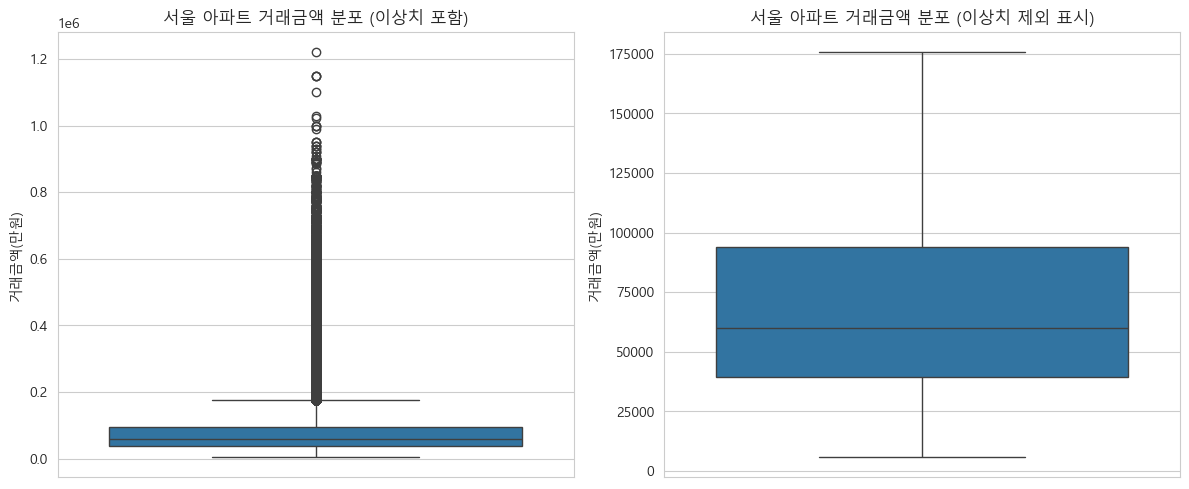

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_trend['거래금액(만원)'], ax=axes[0])
axes[0].set_title('서울 아파트 거래금액 분포 (이상치 포함)')
axes[0].set_ylabel('거래금액(만원)')

sns.boxplot(y=df_trend['거래금액(만원)'], showfliers=False, ax=axes[1])
axes[1].set_title('서울 아파트 거래금액 분포 (이상치 제외 표시)')
axes[1].set_ylabel('거래금액(만원)')

plt.tight_layout()
plt.show()


### 15-2. 평단가 분포 (KDE + 히스토그램)

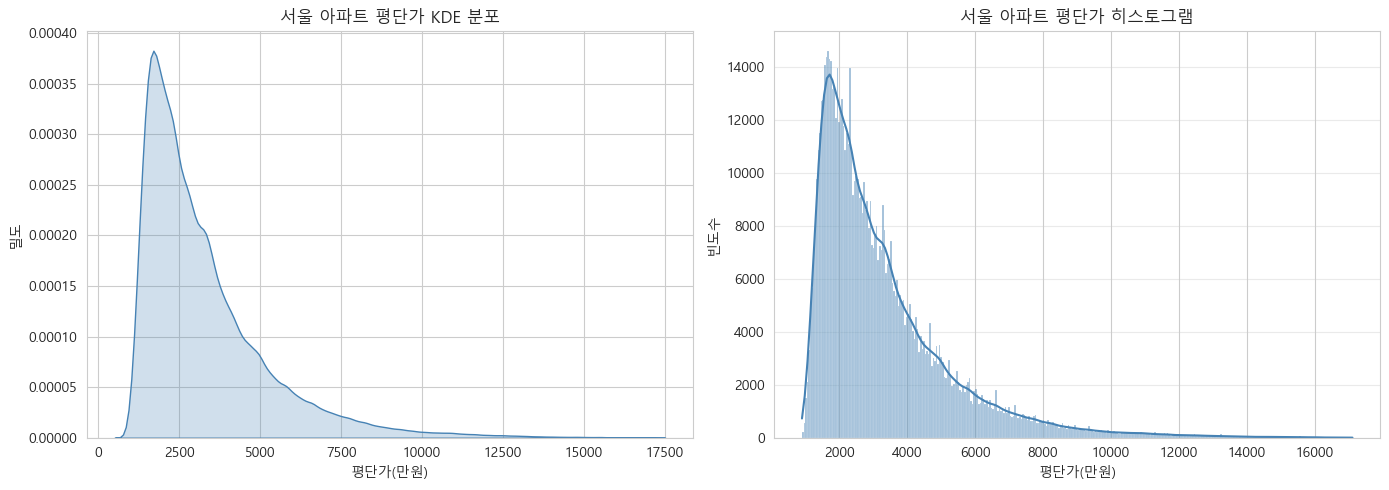

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_trend, x='평당가(만원)', fill=True, ax=axes[0], color='steelblue')
axes[0].set_title('서울 아파트 평단가 KDE 분포')
axes[0].set_xlabel('평단가(만원)')
axes[0].set_ylabel('밀도')

sns.histplot(data=df_trend, x='평당가(만원)', kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('서울 아파트 평단가 히스토그램')
axes[1].set_xlabel('평단가(만원)')
axes[1].set_ylabel('빈도수')
axes[1].grid(axis='y', linestyle='-', alpha=0.4)

plt.tight_layout()
plt.show()


## 16. 구별 분석

서울 25개 구별로 가격 차이 얼마나 나는지, 면적당 가격 패턴이 구마다 어떻게 다른지

### 16-1. 구별 거래금액 분포

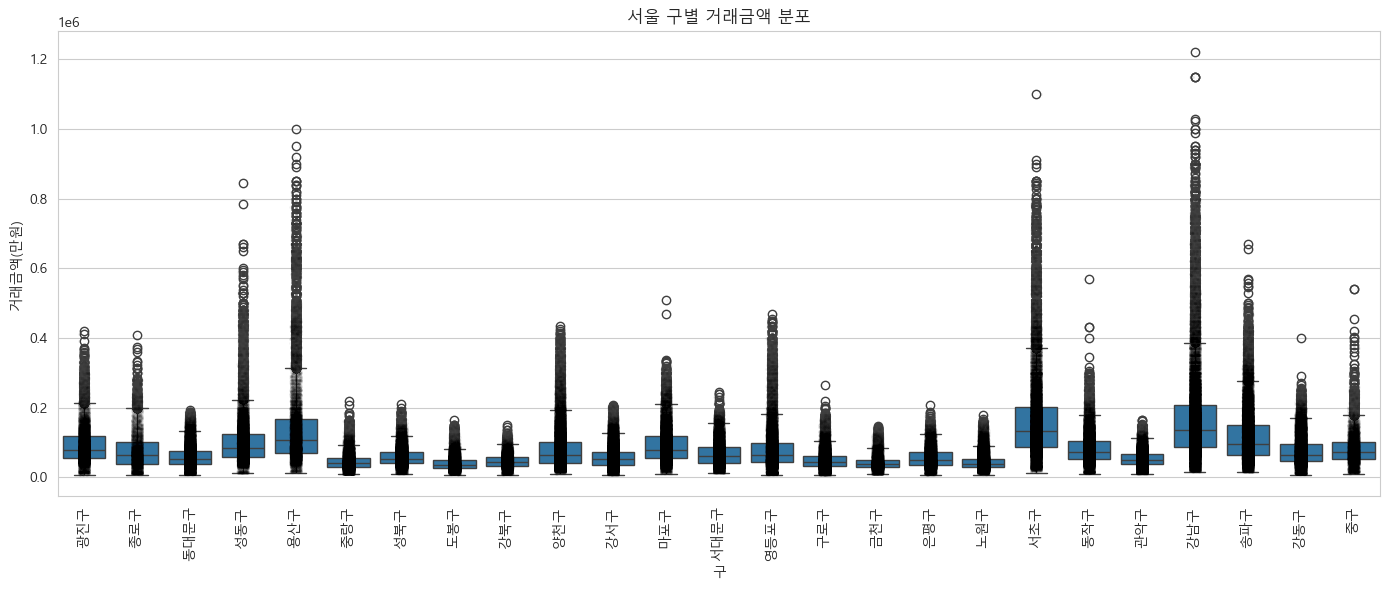

In [34]:
plt.figure(figsize=(14, 6))

sns.boxplot(x='구', y='거래금액(만원)', data=df_trend)
sns.stripplot(x='구', y='거래금액(만원)', data=df_trend, color='black', alpha=0.05, size=2)

plt.xticks(rotation=90)
plt.title('서울 구별 거래금액 분포')
plt.xlabel('구')
plt.ylabel('거래금액(만원)')
plt.tight_layout()
plt.show()


### 16-2. 구별 평단가 순위

평균이랑 중앙값 같이 봄 - 평균만 보면 고가거래 몇건에 순위 휘둘릴 수 있어서

In [35]:
gu_price = (
    df_trend.groupby('구')
    .agg(
        평균평단가=('평당가(만원)', 'mean'),
        중앙평단가=('평당가(만원)', 'median'),
        거래건수=('평당가(만원)', 'count')
    )
    .round(0)
    .astype({'평균평단가': 'int', '중앙평단가': 'int', '거래건수': 'int'})
    .reset_index()
    .sort_values(by='평균평단가', ascending=False)
)
gu_price['순위'] = range(1, len(gu_price) + 1)
gu_price = gu_price[['순위', '구', '평균평단가', '중앙평단가', '거래건수']]

display(gu_price)

top_gu = gu_price.iloc[0]
bottom_gu = gu_price.iloc[-1]
print(f'평단가 1위 : {top_gu["구"]} (평균 {top_gu["평균평단가"]:,}만원)')
print(f'평단가 최하위 : {bottom_gu["구"]} (평균 {bottom_gu["평균평단가"]:,}만원)')
print(f'격차 : {round(top_gu["평균평단가"] / bottom_gu["평균평단가"], 2)}배')


,순위,구,평균평단가,중앙평단가,거래건수
0,1,강남구,6126,5370,44561
14,2,서초구,5532,4493,34368
17,3,송파구,4587,4050,51733
20,4,용산구,4513,3914,15517
15,5,성동구,4071,3556,31441
12,6,마포구,3871,3351,30709
5,7,광진구,3629,3174,15821
11,8,동작구,3396,2996,30605
1,9,강동구,3379,2919,41745
23,10,중구,3299,2928,10580


평단가 1위 : 강남구 (평균 6,126만원)
평단가 최하위 : 도봉구 (평균 1,872만원)
격차 : 3.27배


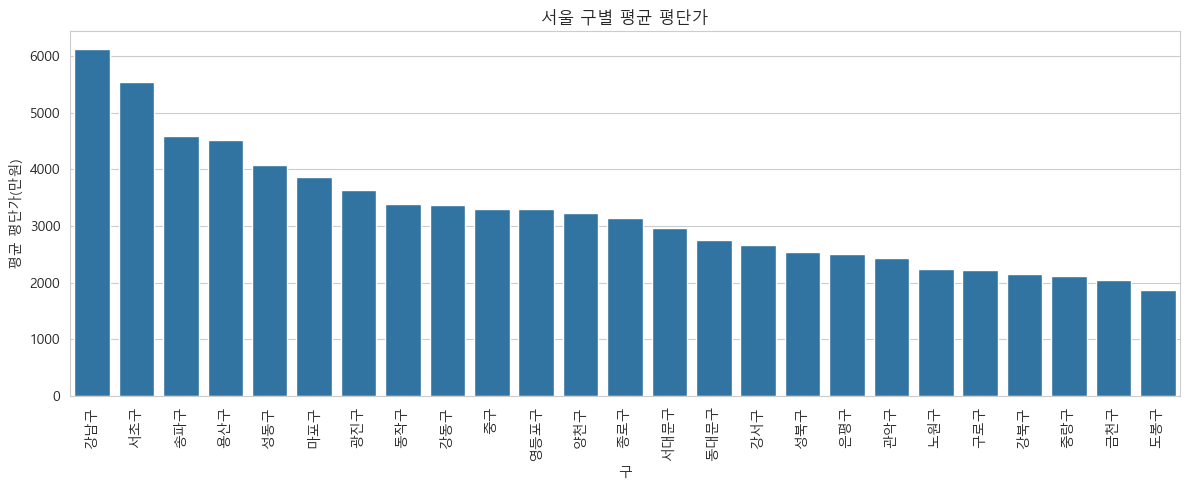

In [36]:
plt.figure(figsize=(12, 5))
sns.barplot(data=gu_price, x='구', y='평균평단가', order=gu_price['구'])
plt.xticks(rotation=90)
plt.title('서울 구별 평균 평단가')
plt.xlabel('구')
plt.ylabel('평균 평단가(만원)')
plt.tight_layout()
plt.show()


### 16-3. 면적 대비 가격 (구별 비교)

같은 면적이라도 구마다 가격 기울기가 다른지 산점도+회귀선으로.
TARGET_GUS 리스트만 바꾸면 다른 구로 볼 수 있음.

여기서는 구별로 1-시그마(평균±표준편차) 벗어나는 거래는 따로 제외함
(위에서 쓴 is_price_outlier랑은 다른, 이 그래프 전용 필터)

In [37]:
def remove_price_outliers_1sigma(df):
    out_list = []
    for key, subdf in df.groupby('구'):
        mean = subdf['거래금액(만원)'].mean()
        std = subdf['거래금액(만원)'].std()
        reduced = subdf[(subdf['거래금액(만원)'] > mean - std) & (subdf['거래금액(만원)'] <= mean + std)]
        out_list.append(reduced)
    return pd.concat(out_list, ignore_index=True)

df_gu_outlier_removed = remove_price_outliers_1sigma(df_trend)
print(f"1-시그마 필터 적용 후: {len(df_gu_outlier_removed):,}건 (전 {len(df_trend):,}건)")


1-시그마 필터 적용 후: 571,686건 (전 773,436건)


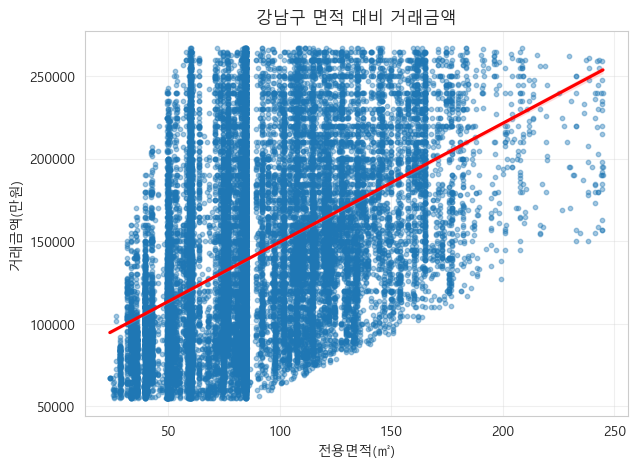

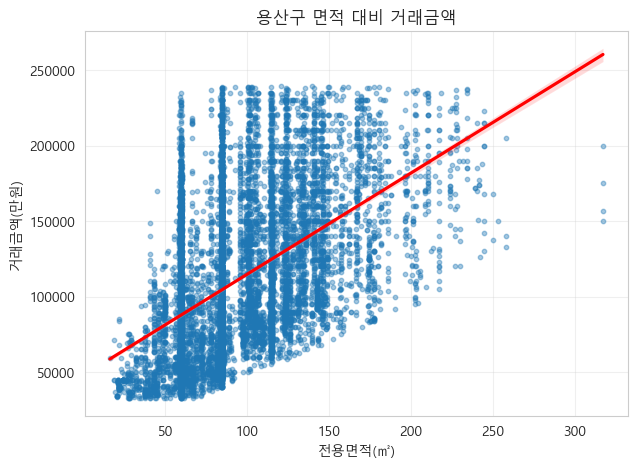

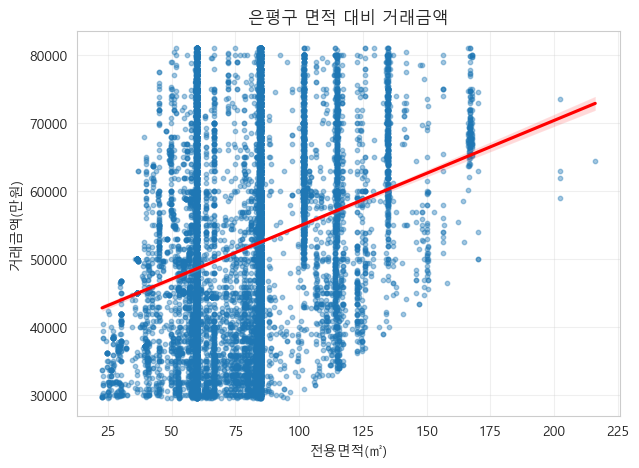

In [38]:
def plot_scatter_chart(df, location):
    temp = df[df['구'] == location]

    plt.figure(figsize=(7, 5))
    plt.scatter(temp['전용면적(㎡)'], temp['거래금액(만원)'], alpha=0.4, s=10)
    sns.regplot(x=temp['전용면적(㎡)'], y=temp['거래금액(만원)'], scatter=False, color='red')

    plt.xlabel('전용면적(㎡)')
    plt.ylabel('거래금액(만원)')
    plt.title(f'{location} 면적 대비 거래금액')
    plt.grid(alpha=0.3)
    plt.show()


TARGET_GUS = ['강남구', '용산구', '은평구']

for gu in TARGET_GUS:
    plot_scatter_chart(df_gu_outlier_removed, gu)


## 17. 연도별 트렌드

11년치 데이터 받은 핵심 이유 - 시간에 따라 가격이 어떻게 움직였는지 보는거

### 17-1. 어느 달에 거래가 제일 많은지

In [39]:
month_count = (
    df_trend.groupby('월')
    .size()
    .reset_index(name='거래량')
    .sort_values(by='거래량', ascending=False)
)
month_count['순위'] = range(1, len(month_count) + 1)
month_count = month_count[['순위', '월', '거래량']]
display(month_count)


,순위,월,거래량
5,1,6,90031
6,2,7,84766
4,3,5,71272
7,4,8,69312
2,5,3,69275
9,6,10,63753
8,7,9,62449
3,8,4,58933
1,9,2,54721
0,10,1,52156


### 17-2. 연도별 서울 전체 평단가 추이

중앙값(이상치에 덜 흔들림) 기준으로, 거래량도 같이

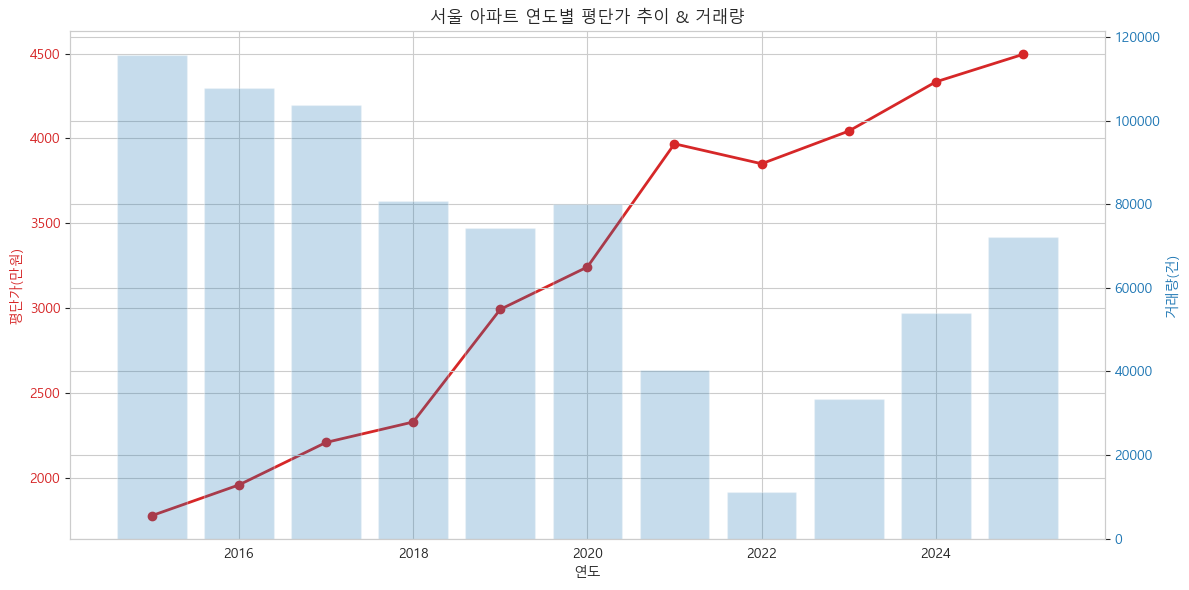

In [40]:
year_trend = (
    df_trend.groupby('연도')
    .agg(평단가_중위=('평당가(만원)', 'median'), 거래량=('평당가(만원)', 'count'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(year_trend['연도'], year_trend['평단가_중위'], color='tab:red', marker='o', linewidth=2, label='평단가(중위)')
ax1.set_xlabel('연도')
ax1.set_ylabel('평단가(만원)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.bar(year_trend['연도'], year_trend['거래량'], alpha=0.25, color='tab:blue', label='거래량')
ax2.set_ylabel('거래량(건)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('서울 아파트 연도별 평단가 추이 & 거래량')
fig.tight_layout()
plt.show()


## 18. 금리 × 매매가 분석

이번에 새로 추가한 부분. 기준금리 바뀔때 평단가/거래량이 어떻게 반응하는지 이중축 그래프로 겹쳐봄.
(왼쪽 축 = 평단가, 오른쪽 축 = 금리)

가설: 금리 오르면 대출부담 커지니까 거래량 줄고 가격상승세 둔화될거같음. 실제로 그런지 그래프로 확인

### 18-1. 연도별 평단가 추이 + 기준금리 겹쳐보기

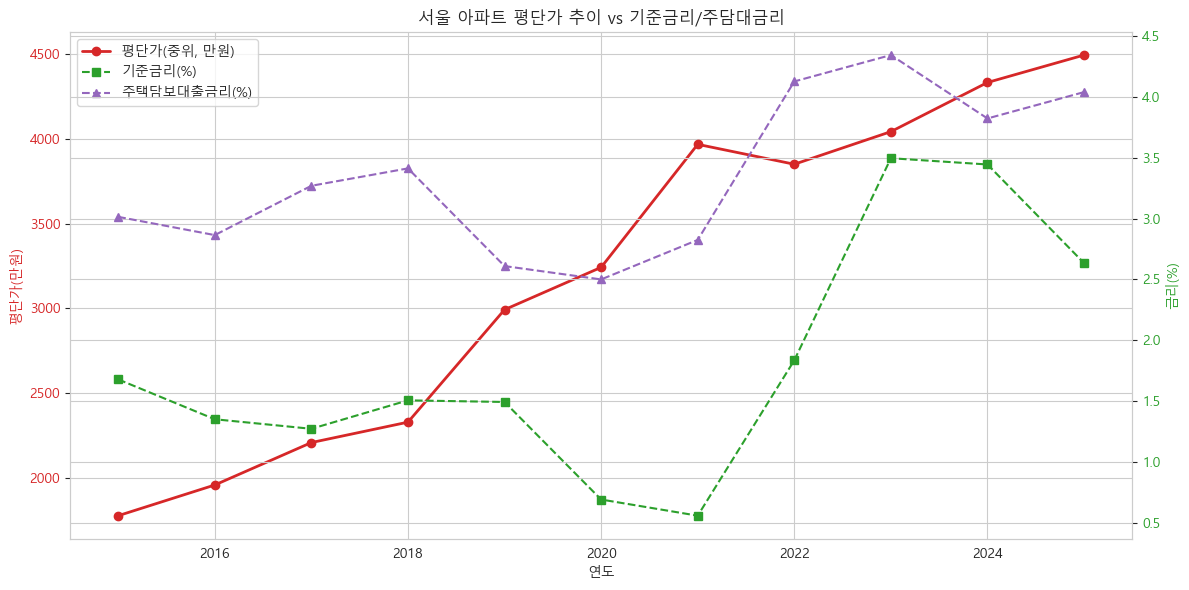

In [41]:
year_rate_trend = (
    df_trend.groupby('연도')
    .agg(
        평단가_중위=('평당가(만원)', 'median'),
        거래량=('평당가(만원)', 'count'),
        기준금리_평균=('기준금리', 'mean'),
        주담대금리_평균=('주택담보대출금리', 'mean')
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# 왼쪽 축 - 평단가
ax1.plot(year_rate_trend['연도'], year_rate_trend['평단가_중위'], color='tab:red', marker='o', linewidth=2, label='평단가(중위, 만원)')
ax1.set_xlabel('연도')
ax1.set_ylabel('평단가(만원)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# 오른쪽 축 - 금리
ax2 = ax1.twinx()
ax2.plot(year_rate_trend['연도'], year_rate_trend['기준금리_평균'], color='tab:green', marker='s', linestyle='--', label='기준금리(%)')
ax2.plot(year_rate_trend['연도'], year_rate_trend['주담대금리_평균'], color='tab:purple', marker='^', linestyle='--', label='주택담보대출금리(%)')
ax2.set_ylabel('금리(%)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('서울 아파트 평단가 추이 vs 기준금리/주담대금리')
fig.tight_layout()
plt.show()


### 18-2. 거래량 + 기준금리 겹쳐보기

금리 오를때 실제로 거래가 줄어드는지

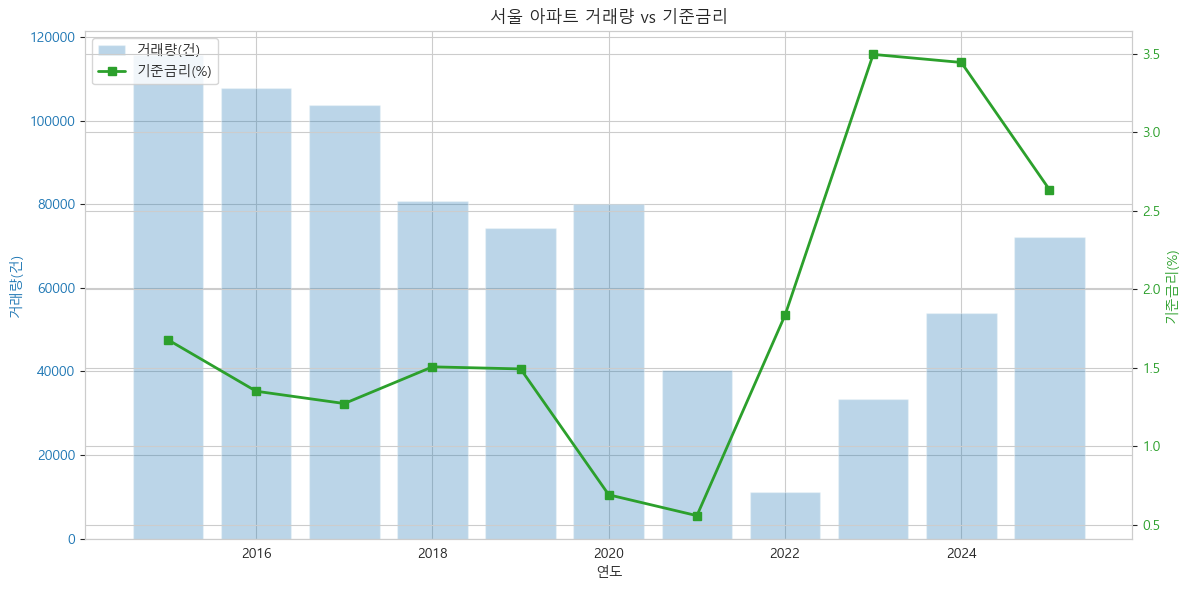

In [42]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(year_rate_trend['연도'], year_rate_trend['거래량'], alpha=0.3, color='tab:blue', label='거래량(건)')
ax1.set_xlabel('연도')
ax1.set_ylabel('거래량(건)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(year_rate_trend['연도'], year_rate_trend['기준금리_평균'], color='tab:green', marker='s', linewidth=2, label='기준금리(%)')
ax2.set_ylabel('기준금리(%)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('서울 아파트 거래량 vs 기준금리')
fig.tight_layout()
plt.show()


### 18-3. 기준금리 구간별 평단가 분포

연도별 그래프 말고, 금리 수준 자체를 저금리/중금리/고금리 구간으로 나눠서 비교

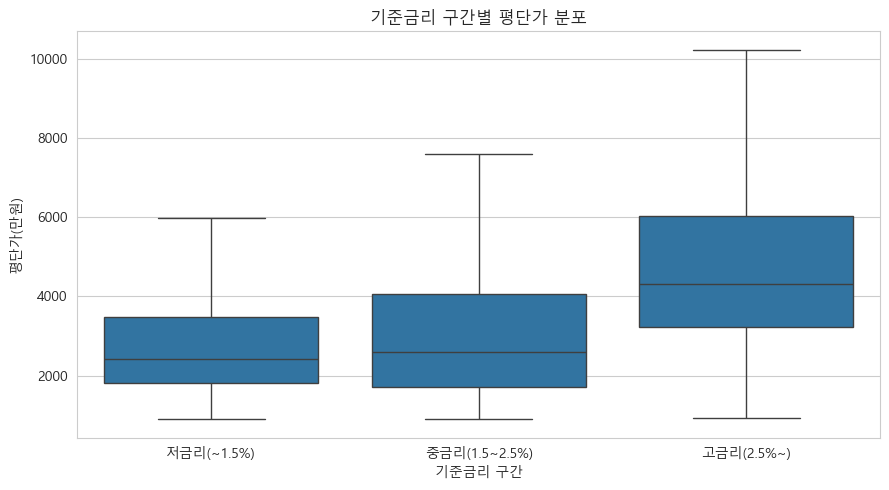

                    median         mean   count
금리구간                                           
저금리(~1.5%)     2424.940400  2900.236679  510922
중금리(1.5~2.5%)  2595.769276  3233.173923  142341
고금리(2.5%~)     4309.552879  4957.720523  120173


In [43]:
df_trend['금리구간'] = pd.cut(
    df_trend['기준금리'],
    bins=[-np.inf, 1.5, 2.5, np.inf],
    labels=['저금리(~1.5%)', '중금리(1.5~2.5%)', '고금리(2.5%~)']
)

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_trend, x='금리구간', y='평당가(만원)', showfliers=False)
plt.title('기준금리 구간별 평단가 분포')
plt.xlabel('기준금리 구간')
plt.ylabel('평단가(만원)')
plt.tight_layout()
plt.show()

print(df_trend.groupby('금리구간', observed=True)['평당가(만원)'].agg(['median', 'mean', 'count']))


## 19. 브랜드별 분석

위에서 만든 브랜드/브랜드등급 컬럼으로 브랜드 유무, 등급에 따라 가격 차이 보기

### 19-1. 일반 vs 하이엔드 평단가 분포

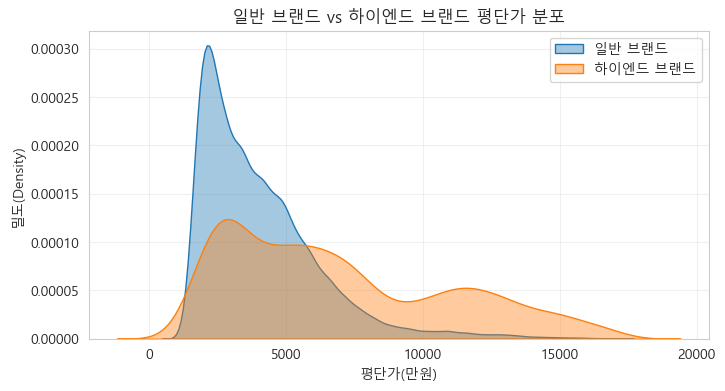

일반 브랜드 거래 건수: 149,669건 | 평단가 중위: 3,503만원
하이엔드 브랜드 거래 건수: 4,111건 | 평단가 중위: 5,991만원


In [44]:
normal_df = df_trend[df_trend['브랜드등급'] == '일반브랜드']
highend_df = df_trend[df_trend['브랜드등급'] == '하이엔드']

plt.figure(figsize=(8, 4))
sns.kdeplot(data=normal_df, x='평당가(만원)', fill=True, alpha=0.4, label='일반 브랜드')
sns.kdeplot(data=highend_df, x='평당가(만원)', fill=True, alpha=0.4, label='하이엔드 브랜드')

plt.title('일반 브랜드 vs 하이엔드 브랜드 평단가 분포')
plt.xlabel('평단가(만원)')
plt.ylabel('밀도(Density)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'일반 브랜드 거래 건수: {len(normal_df):,}건 | 평단가 중위: {normal_df["평당가(만원)"].median():,.0f}만원')
print(f'하이엔드 브랜드 거래 건수: {len(highend_df):,}건 | 평단가 중위: {highend_df["평당가(만원)"].median():,.0f}만원')


### 19-2. 거래금액 / 평단가 / 평형 같이 비교

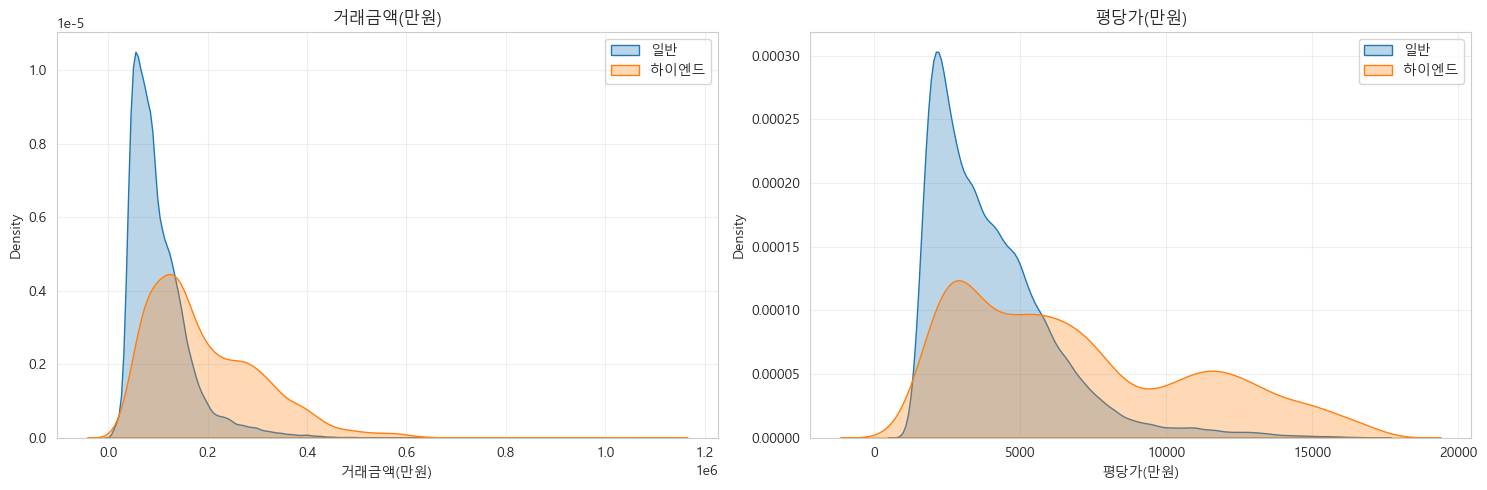

In [45]:
features = ['거래금액(만원)', '평당가(만원)']
if '평형' in df_trend.columns:
    features.append('평형')

plt.figure(figsize=(15, 5))
for i, feature in enumerate(features, 1):
    plt.subplot(1, len(features), i)
    sns.kdeplot(data=normal_df, x=feature, fill=True, alpha=0.3, label='일반')
    sns.kdeplot(data=highend_df, x=feature, fill=True, alpha=0.3, label='하이엔드')
    plt.title(feature)
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 19-3. 브랜드별 평단가 분포 (그리드)

일반 브랜드 10개 한번에 비교

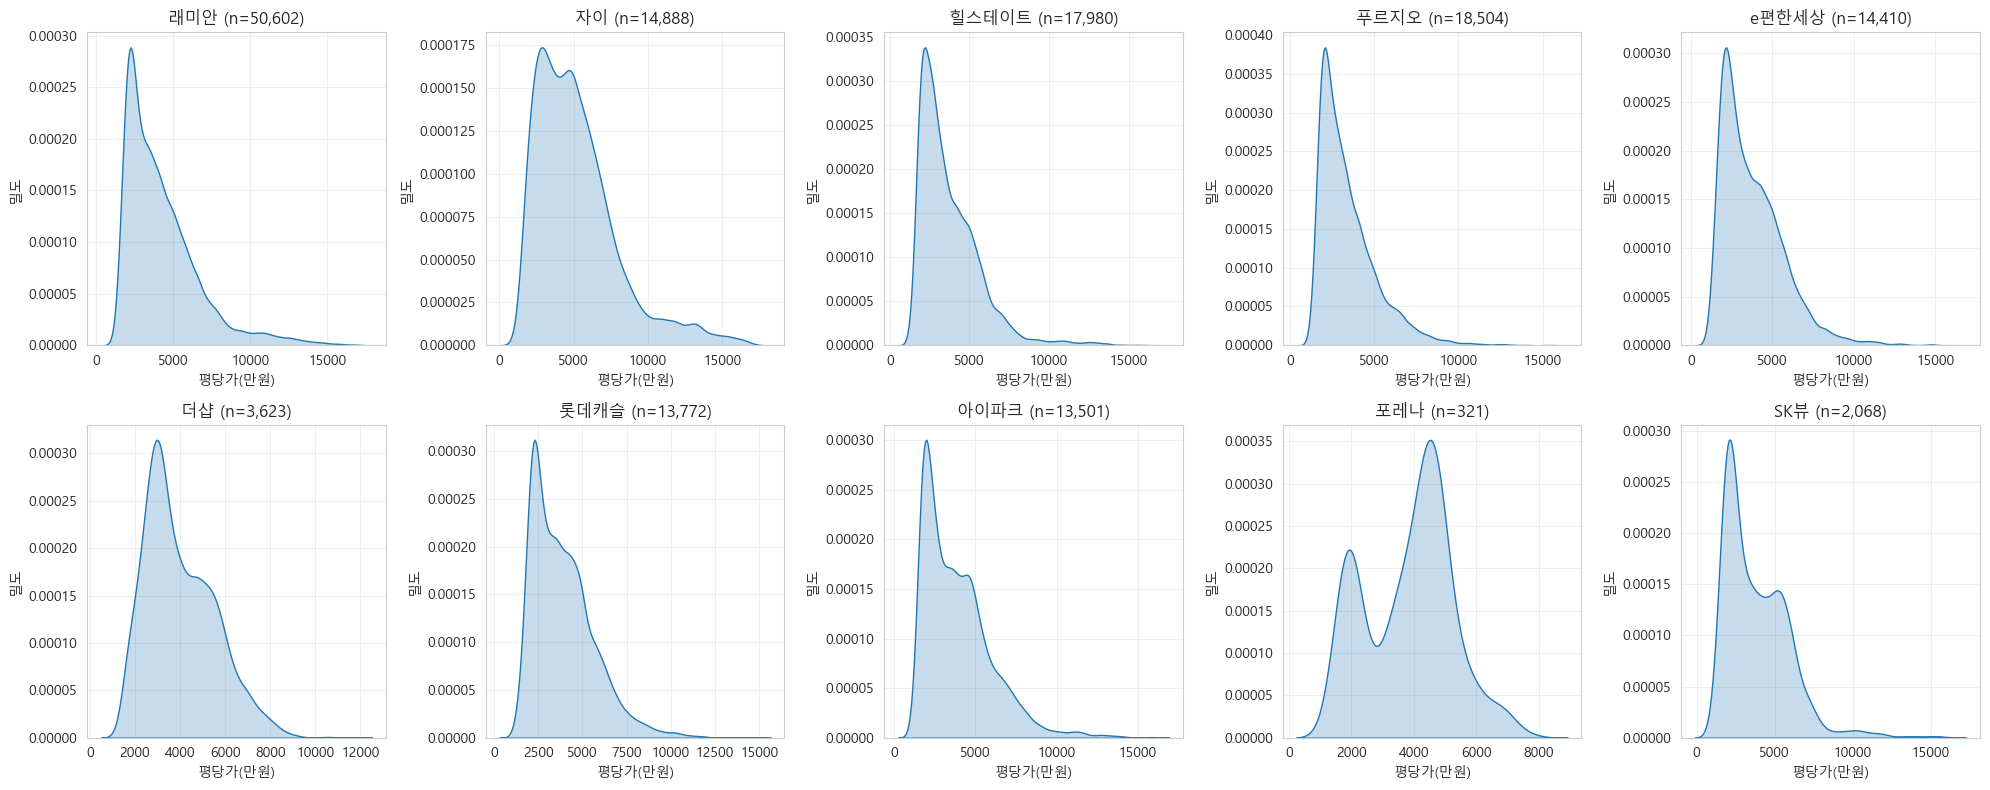

In [46]:
brand_list = ['래미안', '자이', '힐스테이트', '푸르지오', 'e편한세상', '더샵', '롯데캐슬', '아이파크', '포레나', 'SK뷰']

plt.figure(figsize=(20, 8))
for i, brand in enumerate(brand_list, 1):
    plt.subplot(2, 5, i)
    brand_df = df_trend[df_trend['브랜드'] == brand]
    if len(brand_df) < 5:
        plt.title(f'{brand} (표본 부족)')
        continue
    sns.kdeplot(data=brand_df, x='평당가(만원)', fill=True)
    plt.title(f'{brand} (n={len(brand_df):,})')
    plt.xlabel('평당가(만원)')
    plt.ylabel('밀도')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 19-4. 브랜드등급별 평단가 막대비교 (요약)

KDE는 분포 모양 보여주는거고, 숫자로 바로 비교하려면 막대그래프가 더 직관적

,브랜드등급,평단가_중위,거래건수
2,하이엔드,5991.446393,4111
1,일반브랜드,3502.803300,149669
0,기타(브랜드없음),2530.048275,619656


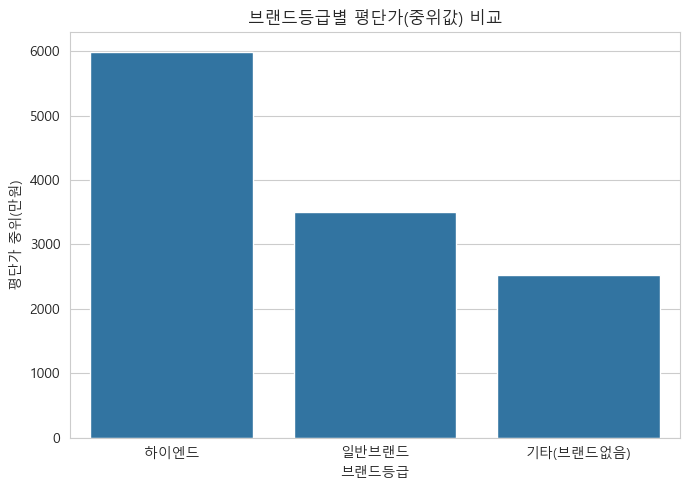

In [47]:
brand_tier_summary = (
    df_trend.groupby('브랜드등급')
    .agg(평단가_중위=('평당가(만원)', 'median'), 거래건수=('평당가(만원)', 'count'))
    .reset_index()
    .sort_values('평단가_중위', ascending=False)
)

display(brand_tier_summary)

plt.figure(figsize=(7, 5))
sns.barplot(data=brand_tier_summary, x='브랜드등급', y='평단가_중위', order=brand_tier_summary['브랜드등급'])
plt.title('브랜드등급별 평단가(중위값) 비교')
plt.xlabel('브랜드등급')
plt.ylabel('평단가 중위(만원)')
plt.tight_layout()
plt.show()


### 19-5. 브랜드 포지셔닝 산점도 (가격 vs 변동성)

KDE나 막대그래프는 브랜드 하나씩 따로 보여줘서 비교가 좀 번거로움.
여기서는 브랜드별로 "평균 가격"과 "가격 변동성(변동계수 CV)"을 동시에 한 그래프에 점으로 찍어서
어떤 브랜드가 비싸면서 안정적인지, 어떤 브랜드가 비싸지만 가격이 들쭉날쭉한지 한눈에 비교함.

변동계수(CV) = 표준편차 / 평균. 값이 낮을수록 가격이 안정적(예측 가능)이고, 높을수록 단지마다 가격 차이가 큼.
점 크기는 거래건수(표본 크기)로 표시 - 거래가 적은 브랜드는 신뢰도가 낮으니 참고용으로만 봐야됨.

In [48]:
# 일반 브랜드 + 하이엔드 브랜드 합쳐서 브랜드별 가격/변동성 계산
all_brands = brand_list + highend_brand_list

brand_position = []
for brand in all_brands:
    sub = df_trend[df_trend['브랜드'] == brand]
    if len(sub) < 10:  # 표본 너무 적은 브랜드는 제외
        continue
    mean_price = sub['평당가(만원)'].mean()
    std_price = sub['평당가(만원)'].std()
    cv = (std_price / mean_price) * 100  # 변동계수 (%)
    tier = '하이엔드' if brand in highend_brand_list else '일반브랜드'
    brand_position.append({
        '브랜드': brand,
        '평단가_평균': mean_price,
        '변동계수(%)': cv,
        '거래건수': len(sub),
        '브랜드등급': tier
    })

brand_position_df = pd.DataFrame(brand_position).sort_values('평단가_평균', ascending=False)
display(brand_position_df)


,브랜드,평단가_평균,변동계수(%),거래건수,브랜드등급
14,래미안원베일리,15615.184413,6.264098,35,하이엔드
11,르엘,13660.917451,11.273270,80,하이엔드
12,디에이치,12131.995674,13.517386,358,하이엔드
13,써밋,6594.151714,47.522487,1068,하이엔드
10,아크로,5997.794198,62.925626,2565,하이엔드
1,자이,5217.416887,53.294171,14888,일반브랜드
0,래미안,4257.896803,56.670365,50602,일반브랜드
5,더샵,3994.264867,38.601874,3623,일반브랜드
7,아이파크,3897.216326,54.061531,13501,일반브랜드
6,롯데캐슬,3894.508260,44.982912,13772,일반브랜드


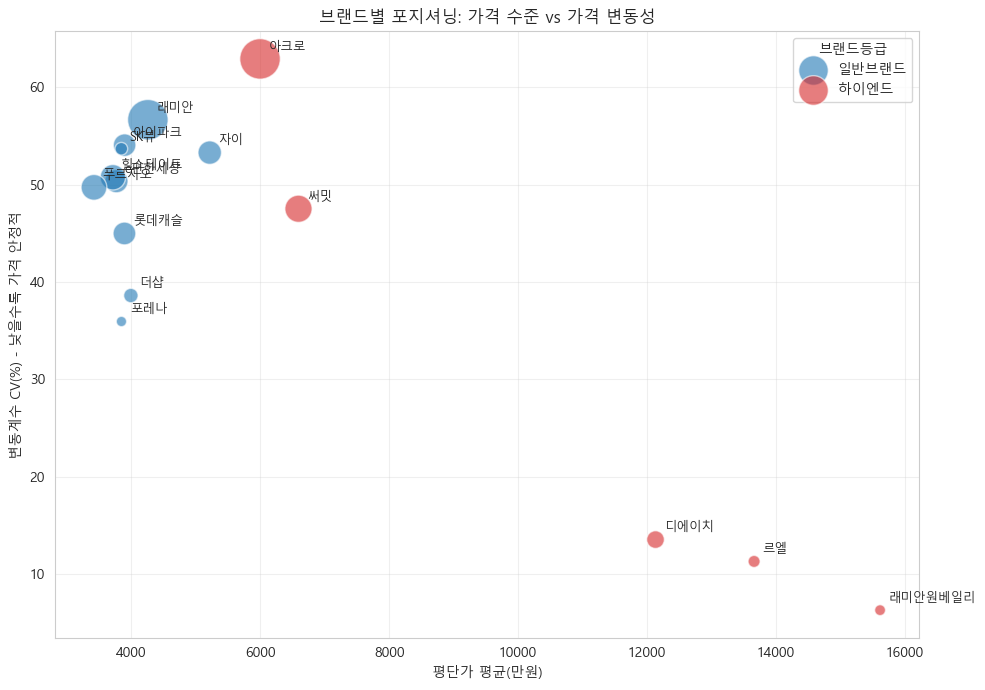

In [49]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'하이엔드': 'tab:red', '일반브랜드': 'tab:blue'}

for tier, group in brand_position_df.groupby('브랜드등급'):
    # 점 크기는 거래건수에 비례 (너무 작거나 크지 않게 스케일 조정)
    sizes = group['거래건수'] / group['거래건수'].max() * 800 + 50
    ax.scatter(
        group['평단가_평균'], group['변동계수(%)'],
        s=sizes, alpha=0.6, label=tier, color=colors[tier], edgecolors='white', linewidth=1
    )

# 점마다 브랜드 이름 표시
for _, row in brand_position_df.iterrows():
    ax.annotate(
        row['브랜드'],
        (row['평단가_평균'], row['변동계수(%)']),
        fontsize=9, xytext=(6, 6), textcoords='offset points'
    )

ax.set_xlabel('평단가 평균(만원)')
ax.set_ylabel('변동계수 CV(%) - 낮을수록 가격 안정적')
ax.set_title('브랜드별 포지셔닝: 가격 수준 vs 가격 변동성')
ax.legend(title='브랜드등급')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


이 그래프 해석하는 법: 오른쪽 아래로 갈수록 "비싸면서 안정적인" 브랜드, 왼쪽 위로 갈수록 "저렴하지만 변동성 큰" 브랜드.
점 크기가 클수록 거래건수가 많아서 신뢰도가 높은 브랜드.

## 20. 코로나 시기 전후 비교

코로나 이후 부동산 폭등기라는 말이 많았는데 실제 데이터로 확인해봄.
기준은 2020년 1월(국내 첫 확진자 발생 시점)로 잡아서 코로나 전/후로 나눔.

- 코로나 전: 2015 ~ 2019
- 코로나 중: 2020 ~ 2022 (사회적 거리두기 등 영향권)
- 코로나 후: 2023 ~ 2025

In [50]:
def covid_period(year):
    if year <= 2019:
        return '코로나 전(~2019)'
    elif year <= 2022:
        return '코로나 중(2020~2022)'
    else:
        return '코로나 후(2023~)'

df_trend['코로나시기'] = df_trend['연도'].apply(covid_period)

covid_order = ['코로나 전(~2019)', '코로나 중(2020~2022)', '코로나 후(2023~)']

covid_summary = (
    df_trend.groupby('코로나시기', observed=True)
    .agg(
        평단가_중위=('평당가(만원)', 'median'),
        평단가_평균=('평당가(만원)', 'mean'),
        거래량=('평당가(만원)', 'count')
    )
    .reindex(covid_order)
)

display(covid_summary)

# 코로나 전 대비 코로나 중 상승률
before = covid_summary.loc['코로나 전(~2019)', '평단가_중위']
during = covid_summary.loc['코로나 중(2020~2022)', '평단가_중위']
after = covid_summary.loc['코로나 후(2023~)', '평단가_중위']

print()
if pd.isna(during) or pd.isna(before):
    print("코로나 전/중 비교: 해당 구간 데이터가 부족해서 계산 못함 (11개 연도 다 합쳤을때 정상적으로 나옴)")
else:
    print(f"코로나 전 -> 코로나 중 평단가 변화: {(during/before - 1)*100:.1f}%")

if pd.isna(after) or pd.isna(during):
    print("코로나 중/후 비교: 해당 구간 데이터가 부족해서 계산 못함 (11개 연도 다 합쳤을때 정상적으로 나옴)")
else:
    print(f"코로나 중 -> 코로나 후 평단가 변화: {(after/during - 1)*100:.1f}%")


,평단가_중위,평단가_평균,거래량
코로나시기,,,
코로나 전(~2019),2143.586418,2532.801047,482252
코로나 중(2020~2022),3501.906780,3985.806178,131651
코로나 후(2023~),4337.452342,4962.035084,159533



코로나 전 -> 코로나 중 평단가 변화: 63.4%
코로나 중 -> 코로나 후 평단가 변화: 23.9%


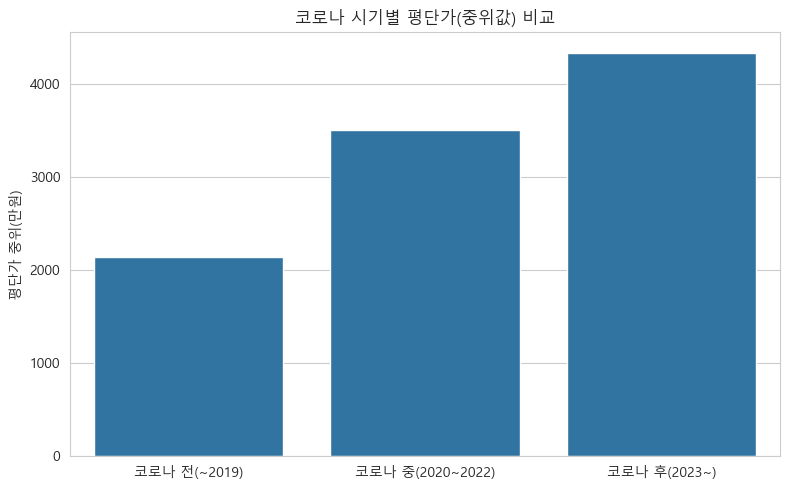

In [51]:
plt.figure(figsize=(8, 5))
sns.barplot(data=covid_summary.reset_index(), x='코로나시기', y='평단가_중위', order=covid_order)
plt.title('코로나 시기별 평단가(중위값) 비교')
plt.xlabel('')
plt.ylabel('평단가 중위(만원)')
plt.tight_layout()
plt.show()


연도별로 더 잘게 쪼개서 보면 코로나 중에서도 어느 해가 제일 많이 올랐는지 보임

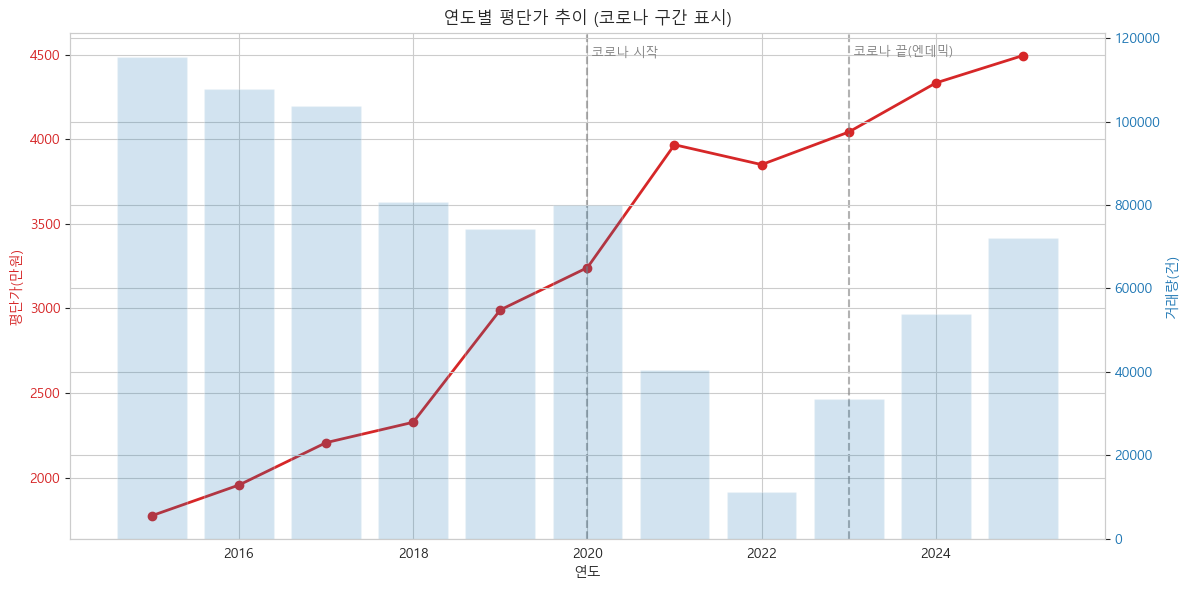

In [52]:
covid_yearly = (
    df_trend.groupby('연도')
    .agg(평단가_중위=('평당가(만원)', 'median'), 거래량=('평당가(만원)', 'count'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(covid_yearly['연도'], covid_yearly['평단가_중위'], color='tab:red', marker='o', linewidth=2)
ax1.set_xlabel('연도')
ax1.set_ylabel('평단가(만원)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# 코로나 시작(2020), 코로나 중 끝(2022) 지점에 세로선 표시
ax1.axvline(x=2020, color='gray', linestyle='--', alpha=0.6)
ax1.axvline(x=2023, color='gray', linestyle='--', alpha=0.6)
ax1.text(2020, ax1.get_ylim()[1]*0.97, ' 코로나 시작', fontsize=9, color='gray')
ax1.text(2023, ax1.get_ylim()[1]*0.97, ' 코로나 끝(엔데믹)', fontsize=9, color='gray')

ax2 = ax1.twinx()
ax2.bar(covid_yearly['연도'], covid_yearly['거래량'], alpha=0.2, color='tab:blue')
ax2.set_ylabel('거래량(건)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('연도별 평단가 추이 (코로나 구간 표시)')
fig.tight_layout()
plt.show()


> **참고**: 기획서에 GDP 등 경제지표도 같이 보겠다고 적어뒀었는데, 이번엔 GDP 데이터 파일을 따로 구하지 못해서 못 넣음.
> 금리 데이터만 가지고 분석함. GDP는 KOSIS에서 따로 받아서 다음 단계에 추가하면 될듯.

## 다음에 더 해볼것

- GDP 데이터 받아서 경제지표 분석 보강 (기획서에 적어둔건데 아직 못함)
- 동 단위로 더 쪼개서 트렌드 보기
- 브랜드 x 구 교차분석 (강남구 하이엔드 vs 노원구 하이엔드 가격차이)
- 금리랑 평단가 상관계수 숫자로 계산
- 평형대별 트렌드 따로 분리
- Streamlit으로 웹 대시보드 만들기 (기획서 4주차 목표)